# 08_NarrativeRisk_LLM_IndustryNeutral

Same tercile spread as quantlet 01 but the composite_severity signal is demeaned within GICS sector before the cross-sectional sort. Demonstrates the methodological choice of orthogonalising against sector-level mean severity. Not intended as evidence.

**Axis exercised:** Within-sector demean

Headline numbers reported below are **indicative not inferential** at N=30 firms x 10 fiscal years and are **not intended as evidence**.


## Why an industry-neutral quantlet?

Quantlet 01 sorts firms on raw composite severity, pooled across all GICS sectors.
That construction implicitly assumes the cross-sectional ranking of severity is informative regardless of which sector each firm operates in.
A firm with composite severity 4.0 ranks the same way against the universe whether it is a financial-services firm (where high risk-language is a baseline expectation) or a utility (where it is unusual).

This is a defensible assumption only if the sector-level mean severity is approximately equal across sectors.
In practice, financials and technology firms write longer, more legally precise risk-factor sections than utilities or consumer staples; their composite severities sit at systematically higher baselines independent of any firm-specific risk signal the LLM is trying to capture.
Sorting on raw severity in the presence of sector-level baselines means the long leg (T3) loads on financials and technology, the short leg (T1) loads on utilities and staples, and the resulting spread captures sector exposure as much as it captures within-sector severity ranking.

The industry-neutral fix is to demean the composite severity within each (sector, signal year) group before the cross-sectional sort.
A firm now ranks based on how its severity compares to the sector mean for that year, not how it compares to the universe-wide mean.
The tercile sort then captures within-sector variation only; the spread is structurally orthogonal to sector membership.

The key point is that the canonical quantlet 01's alpha may not be a clean test of the narrative-risk hypothesis if the spread is partially a sector-tilt bet.
Reading quantlet 08's alpha next to quantlet 01's tells you how much of the canonical alpha is sector tilt versus within-sector signal.


## Methodology

```
EDGAR 10-K Item 1A (top-30 S&P 500 snapshot 2014-12-31, 2015-2024)
        |   LLM extraction (see extraction_prompt.md)
        v
corpus.ndjson.gz (~3000 records: 30 firms x 10 years x 10 themes, severity 0-5)
        |   compute_theme_exposures (mean across 10 themes)
        v
composite_severity per (firm, signal_year)
        |   form_terciles_with_lag (signal_year y-1 -> portfolio_year y)
        v
tercile (or decile) assignments + monthly returns
        |   axis-specific transform: Within-sector demean
        v
industry_neutral_summary.csv + figure(s)
```


## Cross-sectional sort and the lag invariant

The panel design is a year-by-year cross-sectional sort.
Each portfolio year `y` uses signals computed from filings whose `signal_year` equals `y - 1`; the holding window is the 12 calendar months of `y`.
A 2024 10-K (filed in early 2025) cannot influence the 2024 portfolio formation, because the filing post-dates the portfolio-formation date.

This rule is the panel's no-look-ahead invariant.
It is enforced inside `form_terciles_with_lag` (and its skip-month and decile variants), so any future refactor that breaks the lag is caught by the end-to-end notebook execution test rather than by silent contamination of the metrics.

Two consequences of this design are worth noting.
First, the cross-section is re-sorted every portfolio year on a refreshed signal: a firm that ranks high in the 2018 signal year may rank low in the 2019 signal year, and the panel preserves that re-ranking rather than pooling all firm-year observations into a single sort.
Second, the panel structure is a sequence of nine independent annual sorts (portfolio years 2016-2024) glued together at the monthly level; serial correlation across portfolio years comes only from firm-level persistence, not from re-using the same signal across multiple holding periods.

Pooling signals across years (e.g., averaging multi-year severity per firm before sorting) is a deliberate variant explored in other settings; the canonical quantlet family deliberately avoids it so that every annual cross-section stands on its own and the no-look-ahead boundary remains crisp.


## How within-sector demean works mechanically

The implementation lives in `demean_within_sector`.
The function takes the standard signals DataFrame (columns: firm, signal_year, composite_severity) and a firm-list lookup (columns: ticker, sector, sourced from `firm_list.csv`).

For each firm, it merges the GICS sector tag onto the signals row.
For each (sector, signal_year) group, it computes the group mean severity and subtracts it from each member firm's composite_severity.
The output is a signals DataFrame with the same shape, but `composite_severity` now lives on a centred scale (mean zero within each sector-year cell) instead of the original 0-5 scale.

A firm whose original severity was 3.5 in a sector whose mean was 3.0 has demeaned severity 0.5 (above sector mean).
A firm whose original severity was 4.5 in a sector whose mean was 4.5 has demeaned severity 0.0 (at sector mean).
The cross-sectional sort then ranks firms on this demeaned value, so the resulting tercile assignment is based on within-sector severity rank rather than absolute severity rank.

Two implementation properties matter.

First, firms missing from the sector lookup are dropped (with a logged warning) rather than imputed; a firm without a known sector cannot be demeaned and is excluded from the panel for that year.
On the locked top-30 roster every firm has a known GICS sector, so this branch is normally unused; it exists for robustness if the roster is later edited.

Second, the demean is signal-year-specific, not panel-pooled.
Each (sector, signal_year) pair gets its own mean, so a firm whose sector's severity baseline drifts upward over the 10-year window is correctly compared against its sector's contemporaneous baseline rather than a static average.
This matches the lag invariant: signal year `y - 1` produces signal year `y - 1` sector means, used to sort for portfolio year `y`.


In [1]:
from __future__ import annotations

import csv
import gzip
import json
import re
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

HERE = Path.cwd()


In [2]:
from data import (
    CORPUS_PATH,
    PRICES_PATH,
    FF_FACTORS_PATH,
    FIRM_LIST_PATH,
    load_corpus,
    load_prices,
    load_ff_factors,
    load_firm_list,
)


In [3]:
PROVENANCE_PATH = HERE / "provenance.json"   # audit trail (not read at runtime; ships for transparency)
SUMMARY_OUT = HERE / "industry_neutral_summary.csv"
FIGURE_OUT = HERE / "industry_neutral_spread.pdf"


In [4]:
def compute_theme_exposures(corpus_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-firm-year severity into a single composite exposure.

    Composite signal = mean severity across the 10 themes (range 0..5).
    Returns: DataFrame with cols [firm, signal_year, composite_severity].
    """
    agg = (
        corpus_df.groupby(["firm", "year"])["severity_0_5"]
        .mean()
        .reset_index()
        .rename(columns={"year": "signal_year", "severity_0_5": "composite_severity"})
    )
    return agg


In [5]:
def form_terciles_with_lag(signals: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
    """Sort firms into terciles each portfolio_year using ONLY signals where signal_year < portfolio_year.

    For each portfolio_year y in available years (need at least one prior signal year):
      - Use signals from signal_year = y - 1
      - Assign firms to tercile labels {1: low, 2: mid, 3: high} based on composite_severity
      - Apply tercile assignment to that firm's monthly returns over portfolio_year y

    Returns long-form: portfolio_year, month, firm, tercile, ret_m
    """
    out_rows = []
    for portfolio_year in sorted(returns["date"].dt.year.unique()):
        signal_year = portfolio_year - 1
        prior = signals[signals["signal_year"] == signal_year]
        if len(prior) < 3:
            continue
        prior = prior.copy()
        prior["tercile"] = pd.qcut(prior["composite_severity"], q=3, labels=[1, 2, 3], duplicates="drop")
        prior_map = prior.set_index("firm")["tercile"].to_dict()
        year_returns = returns[returns["date"].dt.year == portfolio_year].copy()
        year_returns["tercile"] = year_returns["firm"].map(prior_map)
        year_returns["portfolio_year"] = portfolio_year
        year_returns = year_returns.dropna(subset=["tercile"])
        out_rows.append(
            year_returns[["portfolio_year", "date", "firm", "tercile", "ret_m"]]
            .rename(columns={"date": "month"})
        )
    if not out_rows:
        return pd.DataFrame(columns=["portfolio_year", "month", "firm", "tercile", "ret_m"])
    return pd.concat(out_rows, ignore_index=True)


In [6]:
def demean_within_sector(signals: pd.DataFrame, firm_list: pd.DataFrame) -> pd.DataFrame:
    """Demean composite_severity within (GICS sector, signal_year).

    For each (sector, signal_year) group, subtract the group mean from each firm's
    composite_severity. This orthogonalises the signal against sector-level disclosure
    intensity (e.g., financials systematically use more risk language than utilities),
    so the subsequent tercile sort captures within-sector variation only.

    Args:
        signals: DataFrame with cols [firm, signal_year, composite_severity].
        firm_list: DataFrame with cols [ticker, sector] (from load_firm_list).

    Returns:
        DataFrame with the same shape as signals but composite_severity replaced by
        the within-(sector, signal_year)-demeaned value. Firms not found in
        firm_list are dropped (with a warning).
    """
    merged = signals.merge(
        firm_list.rename(columns={"ticker": "firm"}),
        on="firm",
        how="left",
    )
    n_missing = merged["sector"].isna().sum()
    if n_missing > 0:
        missing_firms = merged.loc[merged["sector"].isna(), "firm"].unique().tolist()
        print(f"WARNING: {n_missing} rows have no sector mapping; dropping: {missing_firms}")
        merged = merged.dropna(subset=["sector"])

    # Within-(sector, signal_year) demean
    group_mean = merged.groupby(["sector", "signal_year"])["composite_severity"].transform("mean")
    merged = merged.copy()
    merged["composite_severity"] = merged["composite_severity"] - group_mean

    return merged[["firm", "signal_year", "composite_severity"]].reset_index(drop=True)


def tercile_spread_test(panel: pd.DataFrame, ff: pd.DataFrame) -> Dict[str, float]:
    """Equal-weight tercile portfolios, compute long-short (T3 - T1) monthly series.

    Returns dict with: tercile_spread_pct_yr, tercile_spread_t_stat_indicative,
                       sharpe_indicative, max_drawdown, n_observations,
                       alpha_pct_yr, alpha_t_stat_indicative.
    Alpha is FF5+UMD risk-adjusted intercept from OLS with HC1 robust SE.
    All metrics are INDICATIVE only (N=30 firms, sector-demeaned, 9 portfolio years).
    """
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "tercile"])["ret_m"].mean().unstack("tercile")
    spread = (bin_returns[3] - bin_returns[1]).dropna()

    n = int(len(spread))
    mean_m = float(spread.mean())
    std_m = float(spread.std(ddof=1))
    annualized_pct = mean_m * 12 * 100
    t_stat = mean_m / (std_m / np.sqrt(n)) if (std_m > 0 and n > 1) else float("nan")
    sharpe = (mean_m / std_m) * np.sqrt(12) if std_m > 0 else float("nan")

    cum = (1 + spread).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = float(drawdown.min()) if len(drawdown) > 0 else float("nan")

    # FF5+UMD risk-adjusted alpha (HC1 robust SE).
    spread_df = spread.rename("spread").reset_index()
    merged = spread_df.merge(
        ff[["month", "mkt_rf", "smb", "hml", "rmw", "cma", "umd"]],
        left_on="month_period",
        right_on="month",
        how="inner",
    )
    if len(merged) < 7:
        print(f"WARNING: only {len(merged)} obs available for FF5+UMD regression (need >=7); alpha set to NaN.")
        alpha_pct_yr = float("nan")
        alpha_t_stat = float("nan")
    else:
        X = sm.add_constant(merged[["mkt_rf", "smb", "hml", "rmw", "cma", "umd"]])
        y = merged["spread"]
        model = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
        alpha_monthly = float(model.params["const"])
        alpha_t_stat = float(model.tvalues["const"])
        alpha_pct_yr = alpha_monthly * 12 * 100

    return {
        "tercile_spread_pct_yr": annualized_pct,
        "tercile_spread_t_stat_indicative": float(t_stat),
        "sharpe_indicative": float(sharpe),
        "max_drawdown": max_dd,
        "n_observations": n,
        "alpha_pct_yr": alpha_pct_yr,
        "alpha_t_stat_indicative": alpha_t_stat,
    }


def plot_industry_neutral_spread(
    panel: pd.DataFrame,
    summary: Dict[str, float],
    out_path: Path = None,
    close: bool = True,
):
    """Plot cumulative-return path of T3, T1, and (T3 - T1) industry-neutral spread; save PDF."""
    if out_path is None:
        out_path = FIGURE_OUT
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "tercile"])["ret_m"].mean().unstack("tercile")
    bin_returns = bin_returns.dropna()
    cum_t1 = (1 + bin_returns[1]).cumprod()
    cum_t3 = (1 + bin_returns[3]).cumprod()
    spread = bin_returns[3] - bin_returns[1]
    cum_spread = (1 + spread).cumprod()

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.plot(cum_t1.index.to_timestamp(), cum_t1.values, label="T1 (low severity, industry-neutral)", linewidth=1.4)
    ax.plot(cum_t3.index.to_timestamp(), cum_t3.values, label="T3 (high severity, industry-neutral)", linewidth=1.4)
    ax.plot(cum_spread.index.to_timestamp(), cum_spread.values, label="T3 - T1 spread (industry-neutral)", linewidth=1.8, color="black")
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative growth (start = 1)")
    ax.set_title("Industry-neutral tercile spread on LLM risk-disclosure severity (2016-2024)")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

    caption = (
        "Within-sector-demeaned tercile-spread code path on "
        "LLM-extracted risk-disclosure severities; indicative not inferential. N=30 firms, "
        "sector-demeaned within GICS sector before sort. "
        f"Annualised raw spread {summary['tercile_spread_pct_yr']:.2f}%/yr; "
        f"FF5+UMD alpha {summary['alpha_pct_yr']:.2f}%/yr (t={summary['alpha_t_stat_indicative']:.2f}); "
        f"n_obs={summary['n_observations']}. Not intended as evidence."
    )
    fig.text(0.5, -0.02, caption, ha="center", va="top", fontsize=8, wrap=True)
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    if close:
        plt.close(fig)
    return fig


In [7]:
corpus = load_corpus()
prices = load_prices()
ff = load_ff_factors()
firm_list = load_firm_list()
print(f"firm_list: {len(firm_list)} firms across {firm_list['sector'].nunique()} sectors")
firm_list['sector'].value_counts()


firm_list: 30 firms across 8 sectors


sector
Information Technology    7
Communication Services    6
Financials                5
Health Care               4
Consumer Staples          4
Energy                    2
Industrials               1
Consumer Discretionary    1
Name: count, dtype: int64

## Why demean by sector?

Industries differ in baseline risk-disclosure verbosity (financials write more, utilities write less). Without sector-neutralisation, a vanilla tercile sort can degenerate into a sector bet rather than a within-sector severity bet. The fix is to demean each firm's composite_severity by the sector mean before the qcut.


In [8]:
raw_signals = compute_theme_exposures(corpus)
signals = demean_within_sector(raw_signals, firm_list)
print('Sector-demeaned composite_severity describe:')
signals['composite_severity'].describe()


Sector-demeaned composite_severity describe:


count    300.000000
mean       0.000000
std        0.687908
min       -2.042857
25%       -0.372321
50%        0.000000
75%        0.450000
max        2.000000
Name: composite_severity, dtype: float64

## FF5+UMD model primer

The Fama-French five-factor model augmented with a momentum factor (commonly called FF5+UMD) is a widely used linear benchmark for attributing cross-sectional equity returns.
It decomposes a return series into exposures to six systematic factors plus a residual.

The six factors are:

- **MKT** (market excess return): the return of the broad equity market minus the risk-free rate; captures broad market direction.
- **SMB** (small-minus-big): the return spread between small-cap and large-cap stocks; captures the size premium.
- **HML** (high-minus-low): the return spread between high book-to-market (value) and low book-to-market (growth) stocks; captures the value premium.
- **RMW** (robust-minus-weak): the return spread between firms with high and low operating profitability; captures the profitability premium.
- **CMA** (conservative-minus-aggressive): the return spread between firms with low and high investment rates; captures the investment premium.
- **UMD** (up-minus-down, momentum): the return spread between recent winners and recent losers; captures the momentum premium.

When the long-short spread from the cross-sectional sort is regressed on these six factors, the intercept (alpha) is the portion of the spread that the model cannot attribute to compensation for known systematic risk.
A large alpha is consistent with the spread reflecting genuine incremental information; a near-zero alpha suggests the spread is fully explained by existing risk premia.

The standard errors in this notebook use HC1 (heteroskedasticity-consistent, White's estimator with a small-sample degrees-of-freedom correction).
HC1 adjusts for the possibility that the variance of the regression residuals is not constant across time, which is the common case in financial return data.
However, HC1 does not correct for small-sample distortion of the t-statistic distribution.
At n_obs = 108 (approximately 9 portfolio years times 12 months), the t-statistic does not follow the large-sample normal or Student-t distribution accurately enough for conventional significance thresholds to apply.
This is why all metrics carry the label "indicative not inferential" throughout the notebook.


In [9]:
panel = form_terciles_with_lag(signals, prices)
summary = tercile_spread_test(panel, ff)
print('=== headline metrics (industry-neutral) ===')
for k, v in summary.items():
    print(f"  {k:35s} = {v:8.4f}" if isinstance(v, float) else f"  {k:35s} = {v}")
pd.DataFrame([summary]).to_csv(SUMMARY_OUT, index=False)


=== headline metrics (industry-neutral) ===
  tercile_spread_pct_yr               =   1.7886
  tercile_spread_t_stat_indicative    =   0.6072
  sharpe_indicative                   =   0.2024
  max_drawdown                        =  -0.3046
  n_observations                      = 108
  alpha_pct_yr                        =   0.5859
  alpha_t_stat_indicative             =   0.2111


## Reading the headline numbers

The notebook prints a dictionary of summary metrics and writes the same numbers to `industry_neutral_summary.csv` for downstream consumption.
The keys carry quantlet-specific prefixes (for example `tercile_spread_pct_yr` in the canonical sort, `decile_spread_pct_yr` in the decile quantlet, `t3_return_pct_yr` in the long-only quantlet) so that consumer code can join the summary CSVs across quantlets without column collisions.

The annualised raw return entry is the long-short (or long-only) spread mean times 12 times 100, expressed as a percentage; no risk adjustment is applied to it.
Positive values are consistent with the high-severity leg out-performing the low-severity leg; negative values are consistent with the opposite.

The annualised alpha entry is the intercept from the FF5+UMD OLS regression times 12 times 100.
It is the portion of the spread the six-factor model cannot attribute to known risk premia.
Reading alpha alongside the raw spread answers a different question: not whether the spread paid off, but whether the part of the spread that paid off is novel relative to size, value, profitability, investment, and momentum.

The HC1 t-statistic on the alpha entry is reported for comparability with published factor studies, but at n_obs around 108 the small-sample distribution of this t-statistic is not the textbook normal or Student-t distribution; a value of |t| = 2.0 is not equivalent to p < 0.05 in any conventional sense.
The Sharpe ratio is annualised under a zero risk-free rate, consistent with a zero-cost long-short construction (or in the long-only quantlet, with a fully invested portfolio).
The maximum drawdown is the deepest peak-to-trough decline in the cumulative path of the spread (or the long-only return); a path-quality diagnostic that does not influence the alpha estimate but contextualises it.

Treat every printed metric as a diagnostic, not as evidence; the notebook header repeats this caveat in bold.


## Reading the industry-neutral alpha

Compare this quantlet's `alpha_pct_yr` to quantlet 01's `alpha_pct_yr`.
The contrast tests how much of the canonical alpha is sector tilt versus within-sector signal.

Pattern A: the industry-neutral alpha is similar in magnitude and sign to the canonical alpha.
This is consistent with the narrative-risk signal being a within-sector phenomenon, with sector membership doing little explanatory work.
A robust signal should produce similar within-sector and pooled alphas; reading the magnitudes side by side tells you that the canonical alpha is not driven by a sector tilt.

Pattern B: the industry-neutral alpha is materially smaller than the canonical alpha (or sign-flipped).
This is consistent with the canonical quantlet's alpha being driven, at least in part, by the long leg loading on high-baseline-severity sectors and the short leg loading on low-baseline-severity sectors.
The reading is that the canonical alpha is not a clean test of within-sector severity ranking; some fraction of it is a sector-tilt bet.
Whether that fraction is "most" or "a little" depends on the magnitude of the contraction; reading the difference is more informative than the absolute level.

Pattern C: the industry-neutral alpha is materially larger than the canonical alpha.
This is consistent with sector-level severity dispersion partially offsetting a within-sector signal in the canonical sort.
Demeaning the signal lets the within-sector component dominate; the resulting alpha may be larger because the sector tilt was working against the signal in the pooled sort.
This pattern is rarer but observed in the literature on factor decomposition.

The most informative comparison is quantlet 01's pooled alpha, quantlet 06 panel (d) (which visualises sector concentration of severity), and quantlet 08's industry-neutral alpha.
Reading all three together tells the reader where the alpha lives: in cross-sector sorting (quantlet 01 only), in within-sector ranking (quantlet 08 only), or in both (similar magnitudes).


## Reading the output relative to quantlet 01

If quantlet 01's alpha shrinks materially after sector neutralisation, the headline result was at least partly a sector tilt rather than a firm-specific disclosure-severity bet.


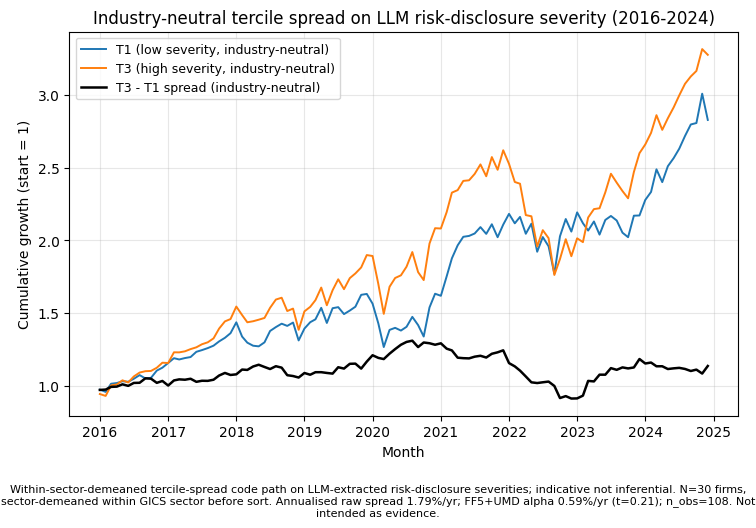

In [10]:
plot_industry_neutral_spread(panel, summary, out_path=FIGURE_OUT)
png_path = FIGURE_OUT.with_suffix('.png')
plot_industry_neutral_spread(panel, summary, out_path=png_path)
display(Image(filename=str(png_path)))


## Caveats

- **Power**: 30 firms split across 3 terciles leaves 10 firms per leg, statistically thin.
- **Severity validity**: severities are LLM (or LM) judgements of disclosure language; not validated against expert ratings or external risk benchmarks.
- **Taxonomy**: the 10-theme list is hand-listed and illustrative; production use would require a data-driven taxonomy.
- **Reproducibility**: `provenance.json` + `extraction_prompt.md` + the `corpus.ndjson.gz` SHA chain enable a full audit of how every severity was produced.


## Reproduction

```
git clone <repo>
cd 08_NarrativeRisk_LLM_IndustryNeutral
make data                  # fetch third-party data + regenerate seed-pinned inputs
make demo                  # this notebook -> industry_neutral_summary.csv + industry_neutral_spread.pdf
make test-all              # quantlet test suite
```
